# Building models

A tengri model is a few blocks of physics — a star-formation history, a dust
law, a nebular backend, optionally an AGN — and a statement of which
parameters are free. The nested-dict grammar (after BAGPIPES) lets you write
that down one block at a time: a dict per group, with `'type'` for the
structural choice and an `'all_params'` wildcard for free/fixed.
(`'all_params'` is the only wildcard spelling; the older `'*'` is retired
and raises ValueError with an error message naming the replacement.)

## Setup

In [1]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # suppress XLA/PjRt C++ INFO+WARNING logs

import sys

os.environ.setdefault("TENGRI_NO_BACKGROUND_COMPILE", "1")

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))
except NameError:
    _nb_dir = os.getcwd()
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))

_src = os.path.join(_repo_root, "src")
if os.path.isdir(os.path.join(_src, "tengri")):
    sys.path.insert(0, _src)
sys.path.insert(0, _repo_root)
sys.path.insert(0, _nb_dir)

import warnings

# Keep the rendered tutorial clean: silence framework notices that do not
# change the science shown here (baked-in nebular, the WavePrecomp blue-band
# approximation, and
# recipe/parameter-provenance notices). Genuine deprecations in user-facing
# calls are fixed in the code, not hidden.
warnings.filterwarnings("ignore", message=".*BakedInBackend.*")
warnings.filterwarnings("ignore", message=".*WavePrecomp.*")
warnings.filterwarnings("ignore", message=".*states no 'all_params' disposition.*")
warnings.filterwarnings("ignore", message=".*Composable AGN.*")
warnings.filterwarnings("ignore", message=".*before the Big Bang.*")
warnings.filterwarnings("ignore", category=RuntimeWarning)

import time
from pathlib import Path

import jax
import numpy as np
import matplotlib.pyplot as plt

import tengri
from _setup import FIG_DIR
from tengri import (
    builders,
    DEFAULT,
    Fixed,
    FREE,
    Observation,
    Parameters,
    parse_groups,
    Photometry,
    recipes,
    SEDModel,
    Uniform,
)
from tengri import cosmology, plot, units

plot.setup_style()

# Quickstart palette + a curated sequential set for the multi-model tours
# below. The viridis-style palette spans cool→warm so a 5-element legend
# stays readable when stacked.
C_POST, C_TRUTH, C_DATA = "#3a76d9", "0.15", "#c3372a"
PALETTE_SEQ = ["#1f4e79", "#2e7ab0", "#4ba6c8", "#e07a3a", "#a02c2c"]  # cool → warm

# Load SSP grid: bare-stellar FSPS+MILES (required by Cue nebular backend
# used in the canonical recipes; wNE files cannot be paired with Cue).
_ssp_name = "fsps_prsc_miles_chabrier.h5"
ssp = tengri.load_ssp(_ssp_name, download=True)

# Lightweight photometry (pre-downloaded, no SVO API calls)
# Span optical → IR for meaningful SED comparisons
filter_names = [
    "galex_fuv",  # Far-UV (1539 Å)
    "galex_nuv",  # Near-UV (2316 Å)
    "sdss_u",  # Optical (blue)
    "sdss_g",  # Optical (green)
    "sdss_r",  # Optical (red)
    "sdss_i",  # Optical (near-IR)
    "sdss_z",  # Optical (far-red)
    "wise_w1",  # Mid-IR (3.4 μm)
    "wise_w2",  # Mid-IR (4.6 μm)
    "wise_w3",  # Mid-IR (12 μm)
]
photometry = Photometry.from_names(filter_names)
observation = Observation(photometry=photometry)

print(f"Loaded SSP grid: {_ssp_name}")
print(f"Photometry: {photometry.n_filters} filters spanning UV→IR")
print(
    f"  {', '.join([b.replace('galex_', 'GALEX-').replace('sdss_', 'SDSS-').replace('wise_', 'WISE-') for b in filter_names])}"
)

Loaded SSP grid: fsps_prsc_miles_chabrier.h5
Photometry: 10 filters spanning UV→IR
  GALEX-fuv, GALEX-nuv, SDSS-u, SDSS-g, SDSS-r, SDSS-i, SDSS-z, WISE-w1, WISE-w2, WISE-w3


## Four construction paths (all equivalent)

The nested-dict API offers four ways to build a model:

1. **Recipe** — curated template for a common scenario
2. **Direct nested dict** — hand-built mapping, JSON-friendly
3. **Builder factories** — `tengri.builders.sfh.dpl(...)` etc., autocomplete-friendly
4. **Round-trip** — extract from existing model, tweak, rebuild

In [2]:
# Path 1: Recipe (curated template)
print("PATH 1: Recipe")
recipe_dict = recipes.star_forming_photometry()
model1 = SEDModel.build(ssp_data=ssp, observation=observation, **recipe_dict)
print(f"  Model: {model1.spec.n_free} free params from recipe")
print(f"  SFH family: {recipe_dict['sfh']['type']}")
print()

# Path 2: Nested-dict direct (hand-built nested dict)
print("PATH 2: Nested-dict direct")
groups_dict = {
    "sfh": {"type": "dpl", "all_params": FREE},
    "dust_attenuation": {
        "type": "two_component",
        "law": "calzetti",
        "all_params": FREE,
    },
    "dust_emission": {"type": "dale2014", "all_params": Fixed(DEFAULT)},
    "neb": {"type": "cue", "all_params": Fixed(DEFAULT)},
    "redshift": Uniform(0.01, 6.0),
    "igm": {"type": "inoue"},
}
model2 = SEDModel.build(ssp_data=ssp, observation=observation, **groups_dict)
print(f"  Model: {model2.spec.n_free} free params from direct dict")
print(
    f"  Free params match recipe: {set(model1.spec.free_params) == set(model2.spec.free_params)}"
)
print()

# Path 3: Builder factories (IDE-friendly, return dicts under the hood)
#
# `tengri.builders.sfh.dpl(...)` carries a real signature listing the
# variant's parameters by short name, so hovering or autocompleting in an
# IDE surfaces `alpha`, `beta`, `tau_gyr`, `log_total_mass` directly. A typo
# (`beat=...`) is rejected immediately with the list of valid names —
# you don't have to wait until SEDModel.build() runs.
print("PATH 3: Builder factories")
factory_groups = {
    "sfh": builders.sfh.dpl(all_params=FREE, log_total_mass=Uniform(9.0, 11.0)),
    "dust_attenuation": {
        "type": "two_component",
        "law": "calzetti",
        "all_params": FREE,
    },
    "dust_emission": {"type": "dale2014", "all_params": Fixed(DEFAULT)},
    "neb": {"type": "cue", "all_params": Fixed(DEFAULT)},
    "redshift": Uniform(0.01, 6.0),
    "igm": {"type": "inoue"},
}
model_factory = SEDModel.build(ssp_data=ssp, observation=observation, **factory_groups)
print(f"  Model: {model_factory.spec.n_free} free params from factory + dict mix")
print(f"  builders.sfh.dpl(all_params=FREE) → {builders.sfh.dpl(all_params=FREE)}")
print(f"  Available SFH variants ({len(builders.sfh.available())} total):")
print(f"    {', '.join(builders.sfh.available()[:8])}, ...")
print()

# Path 4: Round-trip (extract → edit → rebuild)
print("PATH 4: Round-trip")
groups_from_model = model1.spec.to_groups()
# Tweak: pin the redshift to a known value (e.g. a spectroscopic z) instead of
# fitting it — a common real edit that drops one free parameter.
groups_from_model["redshift"] = Fixed(2.0)
model3 = SEDModel.build(ssp_data=ssp, observation=observation, **groups_from_model)
print(f"  Model: {model3.spec.n_free} free params after pinning redshift")
print(f"  Redshift now fixed: {'redshift' not in model3.spec.free_params}")

PATH 1: Recipe


src/tengri/forward/sed_model.py:9156: WildcardPartialFreeWarning: 'all_params: FREE' freed 2 of 3 parameters in group 'dust_attenuation'. These have no declared prior, only Fixed defaults, so they stay pinned:
  dust_f_obscuration
The fit will run with that physics held constant. Pass explicit priors for the ones you meant to vary, e.g. dust_attenuation={'dust_f_obscuration': Uniform(lo, hi)}, or filter WildcardPartialFreeWarning if this is deliberate.
  spec = parse_groups(**groups)


  Model: 9 free params from recipe
  SFH family: dpl

PATH 2: Nested-dict direct
  Model: 8 free params from direct dict
  Free params match recipe: False

PATH 3: Builder factories


src/tengri/forward/sed_model.py:9156: WildcardPartialFreeWarning: sfh={'all_params': FREE} no longer frees metallicity parameters when there is no explicit met block. Before this change, met_logzsol (and other met_* params) were freed by the sfh wildcard.

To free metallicity parameters explicitly, pass either:
  met={'all_params': FREE}
or:
  met={'logzsol': Uniform(-2, 0.2)}

Issue #1796
  spec = parse_groups(**groups)
src/tengri/forward/sed_model.py:9156: WildcardPartialFreeWarning: 'all_params: FREE' freed 2 of 3 parameters in group 'dust_attenuation'. These have no declared prior, only Fixed defaults, so they stay pinned:
  dust_f_obscuration
The fit will run with that physics held constant. Pass explicit priors for the ones you meant to vary, e.g. dust_attenuation={'dust_f_obscuration': Uniform(lo, hi)}, or filter WildcardPartialFreeWarning if this is deliberate.
  spec = parse_groups(**groups)
src/tengri/forward/sed_model.py:9156: WildcardPartialFreeWarning: sfh={'all_params': F

  Model: 8 free params from factory + dict mix
  builders.sfh.dpl(all_params=FREE) → {'type': 'dpl', 'all_params': FREE}
  Available SFH variants (27 total):
    buat08, burst, const, const_exp, continuity, continuity_flex, declining_exp, delayed, ...

PATH 4: Round-trip
  Model: 8 free params after pinning redshift
  Redshift now fixed: True


src/tengri/forward/sed_model.py:9156: WildcardPartialFreeWarning: 'all_params: FREE' freed 2 of 3 parameters in group 'dust_attenuation'. These have no declared prior, only Fixed defaults, so they stay pinned:
  dust_f_obscuration
The fit will run with that physics held constant. Pass explicit priors for the ones you meant to vary, e.g. dust_attenuation={'dust_f_obscuration': Uniform(lo, hi)}, or filter WildcardPartialFreeWarning if this is deliberate.
  spec = parse_groups(**groups)


## Builder factories

`tengri.builders.*` factories provide autocomplete and early error detection.

### SFH variants — 26+ parametrizations

In [3]:
print("SFH Variants Tour")
print("─" * 70)
print(f"Available SFH families: {len(builders.sfh.available())}")
print(f"  Sampling: {builders.sfh.available()[:5]} ... {builders.sfh.available()[-3:]}")
print()

# Build a model with tsnorm (instead of dpl from PATH 3)
groups_sfh_tour = {
    "sfh": builders.sfh.tsnorm(all_params=FREE, skew=Uniform(-1.0, 1.0)),
    "dust_attenuation": {
        "type": "two_component",
        "law": "calzetti",
        "all_params": Fixed(DEFAULT),
    },
    "neb": {"type": "cue", "all_params": Fixed(DEFAULT)},
    "redshift": Fixed(0.05),
}
spec_sfh_tour = parse_groups(**groups_sfh_tour)
print(
    f"tsnorm variant free params: {[p for p in spec_sfh_tour.free_params if p.startswith('sfh_')]}"
)
print("TIP: Swapping SFH families is now one-line: builders.sfh.<variant>(...)")
print()

SFH Variants Tour
──────────────────────────────────────────────────────────────────────
Available SFH families: 27
  Sampling: ['buat08', 'burst', 'const', 'const_exp', 'continuity'] ... ['table', 'tsnorm', 'tsnorm_burst']

tsnorm variant free params: ['sfh_tsnorm_log_total_mass', 'sfh_tsnorm_peak_lbt_gyr', 'sfh_tsnorm_skew', 'sfh_tsnorm_trunc', 'sfh_tsnorm_width_gyr']
TIP: Swapping SFH families is now one-line: builders.sfh.<variant>(...)



/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_81771/3129749585.py:18: WildcardPartialFreeWarning: sfh={'all_params': FREE} no longer frees metallicity parameters when there is no explicit met block. Before this change, met_logzsol (and other met_* params) were freed by the sfh wildcard.

To free metallicity parameters explicitly, pass either:
  met={'all_params': FREE}
or:
  met={'logzsol': Uniform(-2, 0.2)}

Issue #1796
  spec_sfh_tour = parse_groups(**groups_sfh_tour)


### Dust: two-component attenuation + nested emission

In [4]:
print("Dust Model Tour")
print("─" * 70)

# Attenuation and IR emission are two peer groups, each with its own factory.
groups_dust_tour = {
    "sfh": {"type": "tsnorm", "all_params": Fixed(DEFAULT)},
    "dust_attenuation": builders.dust.two_component(
        law="calzetti",
        all_params=FREE,
        tau_bc=Uniform(0.0, 2.0),
    ),
    "dust_emission": builders.dust.emission.dale2014(all_params=Fixed(DEFAULT)),
    "neb": {"type": "cue", "all_params": Fixed(DEFAULT)},
    "redshift": Fixed(0.05),
}
spec_dust_tour = parse_groups(**groups_dust_tour)
print(
    f"two_component + dale2014: {[p for p in spec_dust_tour.free_params if 'dust' in p][:5]} ..."
)
print(f"Summary:\n{spec_dust_tour.summary_str()}")
print()

Dust Model Tour
──────────────────────────────────────────────────────────────────────
two_component + dale2014: ['dust_tau_bc', 'dust_tau_diff'] ...
Summary:
Parameters  SFH: tsnorm
──────────────────────────────────────────────────────────────────
  Dimensions:  2 free, + 47 fixed
  Modules:     nebular=cue, dust_emission=dale2014, dust_attenuation_law=calzetti

  Parameter                        Prior                      Bounds                 Source
  ──────────────────────────────────────────────────────────────────────────────────────────
  dust_tau_bc                      Uniform(0.0, 2.0)          [0, 2]                 [user]
  dust_tau_diff                    Uniform(0.0, 3.0)          [0, 3]                 [all_params FREE]
  ──────────────────────────────────────────────────────────────────────────────────────────
  dust_L_agn_ir                    Fixed                      0                      [all_params Fixed(DEFAULT)]
  dust_Rv                          Fixed       

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_81771/3993542724.py:16: WildcardPartialFreeWarning: 'all_params: FREE' freed 1 of 2 parameters in group 'dust_attenuation'. These have no declared prior, only Fixed defaults, so they stay pinned:
  dust_f_obscuration
The fit will run with that physics held constant. Pass explicit priors for the ones you meant to vary, e.g. dust_attenuation={'dust_f_obscuration': Uniform(lo, hi)}, or filter WildcardPartialFreeWarning if this is deliberate.
  spec_dust_tour = parse_groups(**groups_dust_tour)


### Nebular backends — cue, cloudy, cb19, ssp, none

In [5]:
print("Nebular Backend Tour")
print("─" * 70)
print(f"Available nebular backends: {builders.neb.available()}")
print()

# Try cb19 (adds log_nH parameter)
try:
    groups_neb_tour = {
        "sfh": {"type": "tsnorm", "all_params": Fixed(DEFAULT)},
        "dust_attenuation": {
            "law": "power_law",
            "type": "two_component",
            "all_params": Fixed(DEFAULT),
        },
        "neb": builders.neb.cb19(all_params=FREE, log_nH=Uniform(1.0, 4.0)),
        "redshift": Fixed(0.05),
    }
    spec_neb_tour = parse_groups(**groups_neb_tour)
    neb_params = [p for p in spec_neb_tour.free_params if "neb" in p]
    print(f"cb19 backend free params: {neb_params}")
except Exception as e:
    # Fallback: bare-stellar SSP may not support non-Cue backends
    print(f"cb19 skipped (bare-stellar SSP limitation): {str(e)[:50]}...")
    groups_neb_tour = {
        "sfh": {"type": "tsnorm", "all_params": Fixed(DEFAULT)},
        "dust_attenuation": {
            "law": "power_law",
            "type": "two_component",
            "all_params": Fixed(DEFAULT),
        },
        "neb": builders.neb.cue(all_params=Fixed(DEFAULT)),
        "redshift": Fixed(0.05),
    }
    spec_neb_tour = parse_groups(**groups_neb_tour)
    neb_params = [p for p in spec_neb_tour.free_params if "neb" in p]
    print(f"Fallback: Cue backend (always available): {neb_params}")
print()

Nebular Backend Tour
──────────────────────────────────────────────────────────────────────
Available nebular backends: ['cb19', 'cloudy', 'cue', 'mappings', 'mappings_agn', 'none', 'ssp']

cb19 backend free params: ['neb_co', 'neb_dig_delta_logU', 'neb_dig_frac', 'neb_dno', 'neb_eline_sigma_kms', 'neb_fdust', 'neb_fesc', 'neb_fesc_lya', 'neb_logU', 'neb_log_nH']



/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_81771/361843758.py:18: WildcardPartialFreeWarning: 'all_params: FREE' freed 9 of 11 parameters in group 'neb'. These have no declared prior, only Fixed defaults, so they stay pinned:
  neb_hbfrac, neb_logZ_gas
The fit will run with that physics held constant. Pass explicit priors for the ones you meant to vary, e.g. neb={'hbfrac': Uniform(lo, hi)}, or filter WildcardPartialFreeWarning if this is deliberate.
  spec_neb_tour = parse_groups(**groups_neb_tour)


### IGM absorption with optional DLA

In [6]:
print("IGM Models Tour")
print("─" * 70)

# inoue14 with DLA column density as optional parameter
igm_dict = builders.igm.inoue14(log_n_hi=Uniform(20.0, 22.0))
print(f"builders.igm.inoue14(log_n_hi=...): {igm_dict}")
print("Note: Supplying log_n_hi auto-sets dla=True (Damped Lyman Alpha)")
print()

IGM Models Tour
──────────────────────────────────────────────────────────────────────
builders.igm.inoue14(log_n_hi=...): {'type': 'inoue14', 'dla': True, 'log_n_hi': Uniform(20.0, 22.0), 'other_params': Fixed(DEFAULT)}
Note: Supplying log_n_hi auto-sets dla=True (Damped Lyman Alpha)



### Composable AGN — disc, torus, NLR, FeII, attenuation

In [7]:
print("Composable AGN Tour")
print("─" * 70)

# Build AGN dict using composable factories (do NOT build full SEDModel here)
agn_dict = builders.agn.composable(
    all_params=FREE,
    log_lbol=Uniform(9.42, 13.42),
    disc=builders.agn.disc.multicolor(all_params=FREE),
    torus=builders.agn.torus.skirtor(all_params=Fixed(DEFAULT)),
    nlr=builders.agn.nlr.analytic(),
    feii=builders.agn.feii.none(),
    atten=builders.agn.atten.smc_prevot(all_params=Fixed(DEFAULT)),
)
print(f"Composable AGN dict keys: {list(agn_dict.keys())}")
print(f"  agn_dict['type'] = '{agn_dict['type']}'")
print(f"  agn_dict['disc']['type'] = '{agn_dict['disc']['type']}'")
print(f"  agn_dict['torus']['type'] = '{agn_dict['torus']['type']}'")
print("Tip: Swap any sub-block (disc, torus, nlr) to explore AGN physics.")
print()

Composable AGN Tour
──────────────────────────────────────────────────────────────────────
Composable AGN dict keys: ['type', 'disc', 'torus', 'nlr', 'feii', 'atten', 'log_lbol', 'other_params']
  agn_dict['type'] = 'composable'
  agn_dict['disc']['type'] = 'multicolor'
  agn_dict['torus']['type'] = 'skirtor'
Tip: Swap any sub-block (disc, torus, nlr) to explore AGN physics.



## Parameter provenance and summary

Use `model.spec.summary_str()` to inspect how each parameter got its value.
The tags show the source:

- `[user]` — explicitly specified in your nested dict
- `[all_params FREE]` — matched by wildcard directive
- `[all_params Fixed(DEFAULT)]` — matched by wildcard directive
- `[default]` — registry default (usually fixed at median)

The `neb` group below deliberately states no disposition so the summary can
show `[default]` tags — and the `DefaultFixedParametersWarning` it triggers
is the grammar flagging exactly that: a group you engaged that yielded
nothing free. Stating `{'all_params': Fixed(DEFAULT)}` is how you say it was intentional.

In [8]:
# Build a model with mixed provenance
base_groups = {
    "sfh": {
        "type": "tsnorm",
        "all_params": FREE,
        "skew": Uniform(-1.0, 1.0),
    },  # skew is [user], others are [all_params FREE]
    "dust_attenuation": {
        "type": "two_component",
        "law": "calzetti",
        "all_params": Fixed(DEFAULT),  # All dust params are [all_params Fixed(DEFAULT)]
        "tau_bc": 0.5,  # Override to explicit value (still fixed)
    },
    "neb": {"type": "cue"},  # No wildcard → all use [default]
    "redshift": Fixed(0.05),
    "igm": {"type": "none"},
}
spec = parse_groups(**base_groups)
print("Parameter Summary with Provenance Tags:")
print(spec.summary_str())

Parameter Summary with Provenance Tags:
Parameters  SFH: tsnorm
──────────────────────────────────────────────────────────────────
  Dimensions:  5 free, + 22 fixed
  Modules:     nebular=cue, dust_attenuation_law=calzetti

  Parameter                        Prior                      Bounds                 Source
  ──────────────────────────────────────────────────────────────────────────────────────────
  sfh_tsnorm_log_total_mass        Uniform(7.0, 12.5)         [7, 12.5]              [all_params FREE]
  sfh_tsnorm_peak_lbt_gyr          Uniform(0.5, 12.0)         [0.5, 12]              [all_params FREE]
  sfh_tsnorm_skew                  Uniform(-1.0, 1.0)         [-1, 1]                [user]
  sfh_tsnorm_trunc                 Uniform(1.0, 10.0)         [1, 10]                [all_params FREE]
  sfh_tsnorm_width_gyr             Uniform(0.2, 5.0)          [0.2, 5]               [all_params FREE]
  ─────────────────────────────────────────────────────────────────────────────────────

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_81771/1745539910.py:18: WildcardPartialFreeWarning: sfh={'all_params': FREE} no longer frees metallicity parameters when there is no explicit met block. Before this change, met_logzsol (and other met_* params) were freed by the sfh wildcard.

To free metallicity parameters explicitly, pass either:
  met={'all_params': FREE}
or:
  met={'logzsol': Uniform(-2, 0.2)}

Issue #1796
  spec = parse_groups(**base_groups)


## Vary the SFH family

The nested-dict interface makes it simple to swap structural choices.
Each SFH family carries different parameter names — the parser handles
this automatically.

Below we show how a single base dict + one-line edits capture the same
physics as the old six Parameters(...) blocks.

In [9]:
sfh_families = [
    (
        "tsnorm",
        {
            "sfh_tsnorm_log_total_mass": np.log10(1e10),
            "sfh_tsnorm_peak_lbt_gyr": 3.0,
            "sfh_tsnorm_width_gyr": 2.5,
            "sfh_tsnorm_skew": 0.2,
            "sfh_tsnorm_trunc": 4.0,
        },
    ),
    (
        "dpl",
        {
            "sfh_dpl_log_total_mass": np.log10(1e10),
            "sfh_dpl_alpha": 2.0,
            "sfh_dpl_beta": 1.5,
            "sfh_dpl_tau_gyr": 2.0,
        },
    ),
    (
        "dexp",
        {
            "sfh_dexp_log_total_mass": np.log10(1e10),
            "sfh_dexp_tau_gyr": 2.5,
        },
    ),
    (
        "lnorm",
        {
            "sfh_lnorm_log_total_mass": np.log10(1e10),
            "sfh_lnorm_peak_gyr": 3.0,
            "sfh_lnorm_width_gyr": 0.6,
        },
    ),
    (
        "dirichlet",
        {
            "sfh_dir_log_total_mass": np.log10(1e10),
            "sfh_dir_z_0": 0.6,
            "sfh_dir_z_1": 0.5,
            "sfh_dir_z_2": 0.4,
            "sfh_dir_z_3": 0.3,
            "sfh_dir_z_4": 0.2,
            "sfh_dir_z_5": 0.15,
        },
    ),
]

print("\nSFH Family Comparison")
print("─" * 70)

# Base groups dict: reused for all SFH families, only type changes
base_groups_sfh = {
    "dust_attenuation": {
        "type": "two_component",
        "law": "calzetti",
        "all_params": Fixed(DEFAULT),  # deliberately all-fixed for this demo (#1995)
        "tau_bc": Fixed(0.5),
        "tau_diff": Fixed(0.3),
        "slope": Fixed(-0.7),
    },
    "dust_emission": {"type": "dale2014", "all_params": Fixed(DEFAULT)},
    "neb": {"type": "cue", "all_params": Fixed(DEFAULT)},
    "redshift": Fixed(0.05),
    "igm": {"type": "none"},
}

for sfh_name, _ in sfh_families:
    # Swap SFH family: one-line edit
    groups_variant = base_groups_sfh.copy()
    groups_variant["sfh"] = {
        "type": sfh_name,
        "all_params": Fixed(DEFAULT),
        "met_logzsol": Fixed(-0.1),
    }

    spec_sfh = parse_groups(**groups_variant)
    sfh_params = [p for p in spec_sfh.free_params if p.startswith("sfh_")]
    print(f"{sfh_name:20s}  {len(sfh_params):2d} SFH params (all fixed for this demo)")

print()
print("[TIP] Use tengri.describe(name) to inspect any SFH family or component in detail.")
print("Example: tengri.describe('dpl') shows the parametrization and physics.")


SFH Family Comparison
──────────────────────────────────────────────────────────────────────
tsnorm                 0 SFH params (all fixed for this demo)
dpl                    0 SFH params (all fixed for this demo)
dexp                   0 SFH params (all fixed for this demo)
lnorm                  0 SFH params (all fixed for this demo)
dirichlet              0 SFH params (all fixed for this demo)

[TIP] Use tengri.describe(name) to inspect any SFH family or component in detail.
Example: tengri.describe('dpl') shows the parametrization and physics.


## Radio emission (SF + AGN)

Radio emission combines star-formation-driven synchrotron (from the FIR–radio
correlation) and AGN jets. The grammar uses two peer sub-blocks:
`radio={'sf': {'type': ...}, 'agn': {'type': ...}}`.
The legacy flat `radio_sfr_mode` / `radio_agn_model` parameter form is retired;
the nested structure is now the canonical API.

In [10]:
print("Radio Emission Tour")
print("─" * 70)

# Composable radio: SF driven by Bell 2003 FIRRC, AGN via power-law
groups_radio = {
    "sfh": {"type": "tsnorm", "all_params": Fixed(DEFAULT)},
    "dust_attenuation": {"law": "calzetti", "type": "two_component", "all_params": Fixed(DEFAULT)},
    "neb": {"type": "cue", "all_params": Fixed(DEFAULT)},
    "radio": {
        "sf": {"type": "bell2003"},  # FIR-radio correlation (Bell 2003)
        "agn": {"type": "powerlaw"},  # AGN radio as power-law
        "q_ir": Uniform(2.0, 2.8),  # Vary FIR-radio correlation
    },
    "redshift": Fixed(0.05),
}
spec_radio = parse_groups(**groups_radio)
print("Radio composable (SF + AGN):")
radio_params = [p for p in spec_radio.free_params if p.startswith("radio_")]
print(f"  Free params: {radio_params}")
print("  SF: Bell 2003 FIRRC correlation")
print("  AGN: Power-law radio loudness")
print()

Radio Emission Tour
──────────────────────────────────────────────────────────────────────
Radio composable (SF + AGN):
  Free params: ['radio_q_ir']
  SF: Bell 2003 FIRRC correlation
  AGN: Power-law radio loudness



## X-ray emission

X-ray emission from hot gas, black-hole accretion, and other sources.
The `xray` group selects the model type and parametrizes the spectrum.

In [11]:
print("X-ray Emission Tour")
print("─" * 70)

# X-ray: yang20 model (X-ray from XRB + AGN corona via alpha_ox)
groups_xray = {
    "sfh": {"type": "tsnorm", "all_params": Fixed(DEFAULT)},
    "dust_attenuation": {"law": "calzetti", "type": "two_component", "all_params": Fixed(DEFAULT)},
    "neb": {"type": "cue", "all_params": Fixed(DEFAULT)},
    "xray": {
        "type": "yang20",  # Yang+2020; AGN corona via alpha_ox–L_2500 (Lusso & Risaliti 2016)
        "all_params": Fixed(DEFAULT),
    },
    "redshift": Fixed(0.05),
}
spec_xray = parse_groups(**groups_xray)
print("X-ray model ('yang20'):")
xray_params = [p for p in spec_xray.free_params if p.startswith("xray_")]
print(f"  Free params: {xray_params}")
print("  Type: 'yang20' (AGN corona + XRB)")
print("  Connects to SFR (XRB scaling) and AGN luminosity")
print()

X-ray Emission Tour
──────────────────────────────────────────────────────────────────────
X-ray model ('yang20'):
  Free params: []
  Type: 'yang20' (AGN corona + XRB)
  Connects to SFR (XRB scaling) and AGN luminosity



## Shock emission (composable with nebular)

Shock-driven line emission (MAPPINGS V models) adds to photoionized nebular
emission. The shock bucket defaults to all fixed; to free parameters, use
explicit priors (e.g. `shock={'frac': Uniform(0, 1)}`). The `all_params: FREE`
wildcard is deliberately refused for shock — it is not a silent no-op but a
guard against misconfiguration.

In [12]:
print("Shock Emission Tour")
print("─" * 70)

# Shock with 'frac' (relative) normalization: fraction of the galaxy's Hα
groups_shock_frac = {
    "sfh": {"type": "tsnorm", "all_params": Fixed(DEFAULT)},
    "dust_attenuation": {"law": "calzetti", "type": "two_component", "all_params": Fixed(DEFAULT)},
    "neb": {"type": "cue", "all_params": Fixed(DEFAULT)},
    "shock": {
        "norm": "frac",  # Relative: shock Hα as a fraction of galaxy Hα
        "frac": Uniform(0.0, 0.5),  # Free parameter, 0–50% of Hα
    },
    "redshift": Fixed(0.05),
}
spec_shock_frac = parse_groups(**groups_shock_frac)
print("Shock model (norm='frac'):")
shock_params = [p for p in spec_shock_frac.free_params if p.startswith("shock_")]
print(f"  Free params: {shock_params}")
print("  Normalization: fraction of galaxy Hα")

print()

# Shock with 'lhalpha' (absolute) normalization: absolute Hα luminosity
groups_shock_lha = {
    "sfh": {"type": "tsnorm", "all_params": Fixed(DEFAULT)},
    "dust_attenuation": {"law": "calzetti", "type": "two_component", "all_params": Fixed(DEFAULT)},
    "neb": {"type": "cue", "all_params": Fixed(DEFAULT)},
    "shock": {
        "norm": "lhalpha",  # Absolute: direct shock Hα luminosity
        "log_lhalpha": Uniform(38.0, 42.0),  # log10(L_Hα / erg/s)
    },
    "redshift": Fixed(0.05),
}
spec_shock_lha = parse_groups(**groups_shock_lha)
print("Shock model (norm='lhalpha'):")
shock_params_lha = [p for p in spec_shock_lha.free_params if p.startswith("shock_")]
print(f"  Free params: {shock_params_lha}")
print("  Normalization: absolute Hα luminosity (AGN/outflow shocks)")
print()

Shock Emission Tour
──────────────────────────────────────────────────────────────────────
Shock model (norm='frac'):
  Free params: ['shock_frac']
  Normalization: fraction of galaxy Hα

Shock model (norm='lhalpha'):
  Free params: ['shock_log_lhalpha']
  Normalization: absolute Hα luminosity (AGN/outflow shocks)



## Metallicity group

The `met` group selects how metallicity evolves with age. Available modes
include scalar (`table`, `ramp`, and parametric families). For notebook
construction (runtime build), we use a tabular mode or the `logzsol` scalar.

In [13]:
print("Metallicity Modes Tour")
print("─" * 70)

# Available metallicity modes (live list)
from tengri import list_metallicity_modes

met_modes = list_metallicity_modes()
mode_names = [m["name"] for m in met_modes]
print(f"Available metallicity modes ({len(mode_names)} total):")
print(f"  {', '.join(mode_names[:5])}, ...")

print()

# Example 1: scalar metallicity (simplest)
groups_met_scalar = {
    "sfh": {"type": "tsnorm", "all_params": Fixed(DEFAULT)},
    "met": {"logzsol": Uniform(-0.5, 0.3)},  # Vary scalar metallicity
    "dust_attenuation": {"law": "calzetti", "type": "two_component", "all_params": Fixed(DEFAULT)},
    "neb": {"type": "cue", "all_params": Fixed(DEFAULT)},
    "redshift": Fixed(0.05),
}
spec_met_scalar = parse_groups(**groups_met_scalar)
print("Metallicity (scalar logzsol):")
met_params = [p for p in spec_met_scalar.free_params if p.startswith("met_")]
print(f"  Free params: {met_params}")
print("  Mode: constant metallicity over lookback time")

print()

# Example 2: table mode (pre-built or runtime Z(t) histories)
# For notebook construction, table mode requires external data, so we show
# the other modes available via list_metallicity_modes() instead.
print("Other metallicity modes available:")
modes = list_metallicity_modes()
all_mode_names = [m["name"] for m in modes]
other_modes = [m for m in all_mode_names if m not in ["table", "solar"]]
if other_modes:
    print(f"  {', '.join(other_modes[:3])}, ...")

print()
print("[TIP] Use tengri.list_metallicity_modes() for the complete menu.")
print()

Metallicity Modes Tour
──────────────────────────────────────────────────────────────────────
Available metallicity modes (10 total):
  bins, bins_continuity, chem_evol, delta, massmap_box, ...

Metallicity (scalar logzsol):
  Free params: ['met_logzsol']
  Mode: constant metallicity over lookback time

Other metallicity modes available:
  bins, bins_continuity, chem_evol, ...

[TIP] Use tengri.list_metallicity_modes() for the complete menu.



## Round-trip: build, extract, rebuild

A complete round-trip test: build a model, extract its structure via
`to_groups()`, tweak one parameter, rebuild, and verify the structure matches.
This demonstrates the invertibility of the nested-dict grammar.

In [14]:
print("Round-trip Verification")
print("─" * 70)

# Build a complete model with multiple blocks
groups_roundtrip = {
    "sfh": {"type": "tsnorm", "all_params": FREE, "skew": Uniform(-1.0, 1.0)},
    "met": {"logzsol": Uniform(-0.5, 0.3)},
    "dust_attenuation": {
        "type": "two_component",
        "law": "calzetti",
        "all_params": Fixed(DEFAULT),
        "tau_bc": Fixed(0.5),
        "tau_diff": Fixed(0.3),
        "slope": Fixed(-0.7),
    },
    "dust_emission": {"type": "dale2014", "all_params": Fixed(DEFAULT)},
    "neb": {"type": "cue", "all_params": Fixed(DEFAULT)},
    "igm": {"type": "inoue"},  # Enable IGM absorption
    "redshift": Uniform(0.01, 0.1),
}

# Build the model
model_rt = SEDModel.build(ssp_data=ssp, observation=observation, **groups_roundtrip)
print(f"Built model: {model_rt.spec.n_free} free params")
print(f"  Free params: {model_rt.spec.free_params}")

# Extract structure back to groups dict
groups_extracted = model_rt.spec.to_groups()

# Verify the round-trip: rebuild from extracted groups
model_rebuilt = SEDModel.build(ssp_data=ssp, observation=observation, **groups_extracted)
print(f"\nRound-trip rebuilt: {model_rebuilt.spec.n_free} free params")
print(f"  Free params: {model_rebuilt.spec.free_params}")

# Verify: free_params sets must match
match = set(model_rt.spec.free_params) == set(model_rebuilt.spec.free_params)
print("\nRound-trip verification:")
print(f"  Free params match: {match}")
print(f"  n_free match: {model_rt.spec.n_free == model_rebuilt.spec.n_free}")

if match:
    print("  ✓ Round-trip successful")
else:
    print("  ✗ Round-trip mismatch (see diagnostic output above)")

Round-trip Verification
──────────────────────────────────────────────────────────────────────
Built model: 7 free params
  Free params: ['met_logzsol', 'redshift', 'sfh_tsnorm_log_total_mass', 'sfh_tsnorm_peak_lbt_gyr', 'sfh_tsnorm_skew', 'sfh_tsnorm_trunc', 'sfh_tsnorm_width_gyr']

Round-trip rebuilt: 7 free params
  Free params: ['met_logzsol', 'redshift', 'sfh_tsnorm_log_total_mass', 'sfh_tsnorm_peak_lbt_gyr', 'sfh_tsnorm_skew', 'sfh_tsnorm_trunc', 'sfh_tsnorm_width_gyr']

Round-trip verification:
  Free params match: True
  n_free match: True
  ✓ Round-trip successful


## SED under different SFH families

One truth dict per SFH family, the resulting SED beside it. The recent
star-formation signature in the UV is what moves most as the family changes.

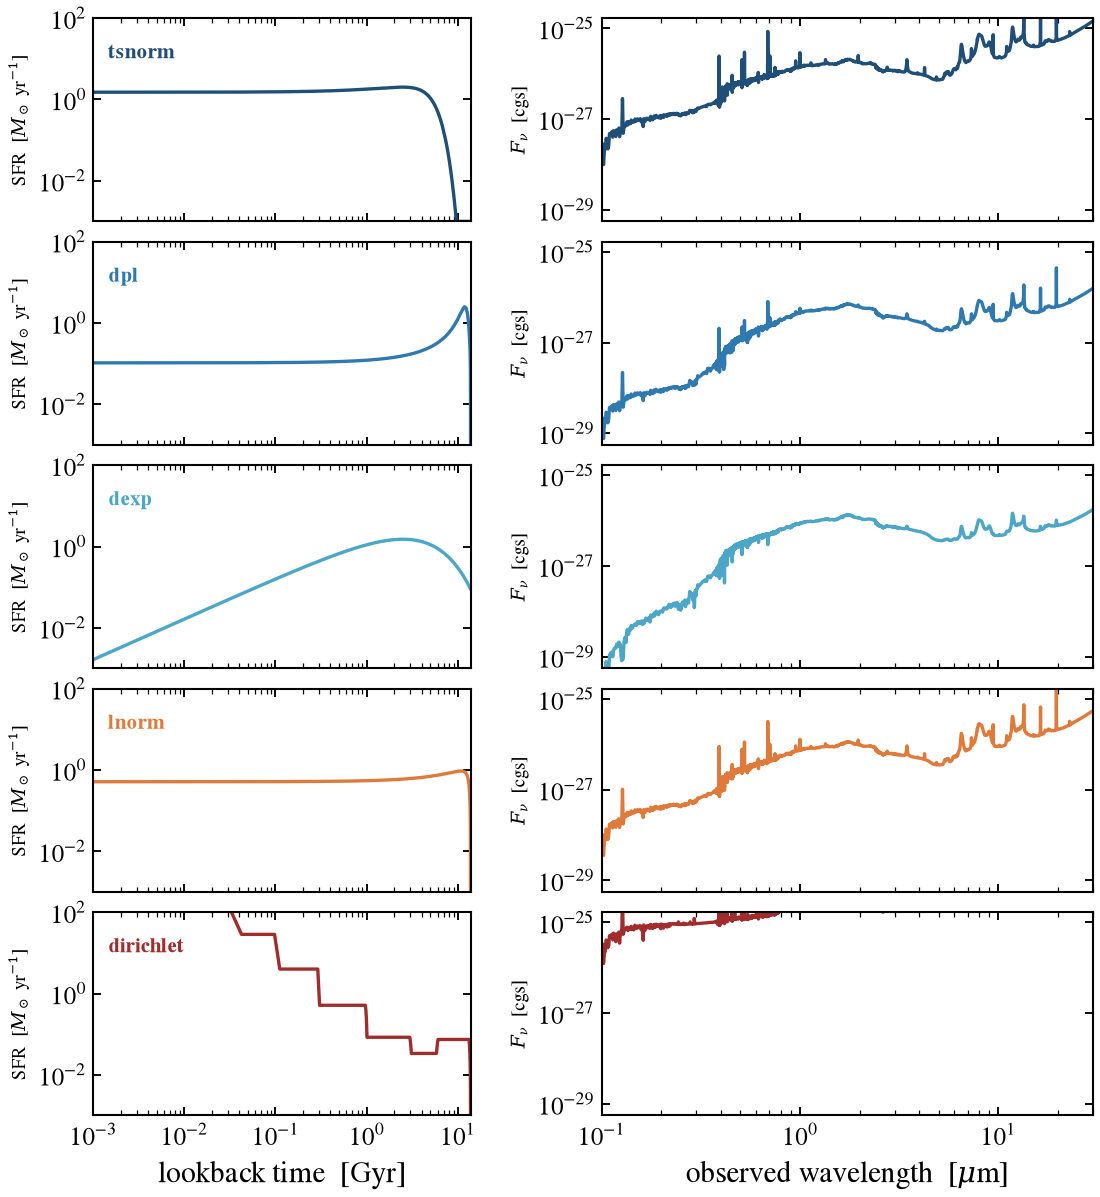

In [15]:
n_sfh = len(sfh_families)
fig = plt.figure(figsize=(8.6, 1.9 * n_sfh))
gs = fig.add_gridspec(n_sfh, 2, hspace=0.10, wspace=0.30, width_ratios=[1, 1.3])

z = 0.05
dl_cm = float(cosmology.luminosity_distance(z))

# Collect every SED first so we can share the y-axis range across the column.
sed_rows = []
for sfh_name, truth_sfh in sfh_families:
    groups_sfh_fig = {
        "sfh": {"type": sfh_name, "all_params": Fixed(DEFAULT), "met_logzsol": Fixed(-0.1)},
        "dust_attenuation": {
            "type": "two_component",
            "law": "calzetti",
            "all_params": Fixed(DEFAULT),  # deliberately all-fixed for this figure (#1995)
            "tau_bc": Fixed(0.5),
            "tau_diff": Fixed(0.3),
            "slope": Fixed(-0.7),
        },
        "dust_emission": {"type": "dale2014", "all_params": Fixed(DEFAULT)},
        "neb": {"type": "cue", "all_params": Fixed(DEFAULT)},
        "redshift": Fixed(z),
        "igm": {"type": "none"},
    }
    spec = parse_groups(**groups_sfh_fig)
    model = SEDModel(spec, ssp, observation=observation)
    truth = {
        **truth_sfh,
        "met_logzsol": -0.1,
        "dust_tau_bc": 0.5,
        "dust_tau_diff": 0.3,
        "dust_slope": -0.7,
        "redshift": z,
    }
    sfr_curve = model.predict_sfh(truth)
    pred = model.predict(truth)
    wave_obs_um = np.asarray(pred.wave_rest) * (1.0 + z) / 1e4
    sed_fnu = np.asarray(units.lnu_to_fnu(pred.rest_sed(), dl_cm, z))
    sed_rows.append(
        {
            "name": sfh_name,
            "t_gyr": np.asarray(sfr_curve["t_gyr"]),
            "sfr": np.asarray(sfr_curve["sfr_mean"]),
            "wave_um": wave_obs_um,
            "fnu": sed_fnu,
        }
    )

mask_w = (sed_rows[0]["wave_um"] >= 0.1) & (sed_rows[0]["wave_um"] <= 30)
all_fnu = np.concatenate([r["fnu"][mask_w] for r in sed_rows])
all_fnu = all_fnu[all_fnu > 0]
y_med = np.median(all_fnu)
y_lo, y_hi = y_med / 1e3, y_med * 30

for row, info in enumerate(sed_rows):
    color = PALETTE_SEQ[row % len(PALETTE_SEQ)]

    ax_sfr = fig.add_subplot(gs[row, 0])
    ax_sfr.loglog(info["t_gyr"], np.maximum(info["sfr"], 1e-3), lw=1.6, color=color)
    ax_sfr.text(
        0.04,
        0.88,
        info["name"],
        transform=ax_sfr.transAxes,
        ha="left",
        va="top",
        color=color,
        fontsize=10,
        weight="bold",
    )
    ax_sfr.set_xlim(1e-3, 14)
    ax_sfr.set_ylim(1e-3, 1e2)
    ax_sfr.set_ylabel(r"SFR  [$M_\odot$ yr$^{-1}$]", fontsize=9)
    if row < n_sfh - 1:
        plt.setp(ax_sfr.get_xticklabels(), visible=False)
    else:
        ax_sfr.set_xlabel("lookback time  [Gyr]")

    ax_sed = fig.add_subplot(gs[row, 1])
    ax_sed.loglog(info["wave_um"][mask_w], info["fnu"][mask_w], lw=1.6, color=color)
    ax_sed.set_xlim(0.1, 30)
    ax_sed.set_ylim(y_lo, y_hi)
    ax_sed.set_ylabel(r"$F_\nu$  [cgs]", fontsize=9)
    if row < n_sfh - 1:
        plt.setp(ax_sed.get_xticklabels(), visible=False)
    else:
        ax_sed.set_xlabel(r"observed wavelength  [$\mu$m]")

fig.savefig(FIG_DIR / "04_sfh_family_grid.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "04_sfh_family_grid.pdf", bbox_inches="tight")

## Vary the dust attenuation law

SFH fixed at tsnorm, sweep the attenuation law. Both the amount of
attenuation and the shape of the curve move the UV-to-optical ratio and the
overall tilt. Only the `law` value changes between models here — swapping
it re-declares the relevant dust parameters automatically.

In [16]:
dust_laws = [
    "calzetti",
    "salim",
    "smc",
    "kriek_conroy",
    "cardelli",
    "noll09",
]

print("\nDust Law Comparison")
print("─" * 70)

# Base groups dict: dust law is the only thing that changes
base_groups_dust = {
    "sfh": {
        "type": "tsnorm",
        "log_total_mass": Fixed(np.log10(1e10)),
        "peak_lbt_gyr": Fixed(3.0),
        "width_gyr": Fixed(2.5),
        "skew": Fixed(0.2),
        "trunc": Fixed(4.0),
    },
    "dust_attenuation": {
        "law": "power_law",
        "type": "two_component",
        "all_params": Fixed(DEFAULT),  # deliberately all-fixed for this demo (#1995)
        "tau_bc": Fixed(0.5),
        "tau_diff": Fixed(0.3),
        "slope": Fixed(-0.7),
    },
    "dust_emission": {"type": "dale2014", "all_params": Fixed(DEFAULT)},
    "neb": {"type": "cue", "all_params": Fixed(DEFAULT)},
    "redshift": Fixed(0.05),
    "igm": {"type": "none"},
}

for dust_law in dust_laws:
    # Swap dust law: one-line edit
    groups_dust_var = base_groups_dust.copy()
    groups_dust_var["dust_attenuation"] = base_groups_dust["dust_attenuation"].copy()
    groups_dust_var["dust_attenuation"]["law"] = dust_law

    spec = parse_groups(**groups_dust_var)
    free_dust = [p for p in spec.free_params if p.startswith("dust_")]
    print(f"{dust_law:20s}  dust free params: {free_dust}")


Dust Law Comparison
──────────────────────────────────────────────────────────────────────
calzetti              dust free params: []
salim                 dust free params: []
smc                   dust free params: []
kriek_conroy          dust free params: []
cardelli              dust free params: []
noll09                dust free params: []


## SED under different attenuation laws

Dust law choice affects the UV-optical tilt and features like the 2175 Å
bump (present in Milky Way + starburst templates, absent in SMC-like laws).
Left panel compares SEDs with no dust; right panel shows impact of each
dust law on the intrinsic spectrum.

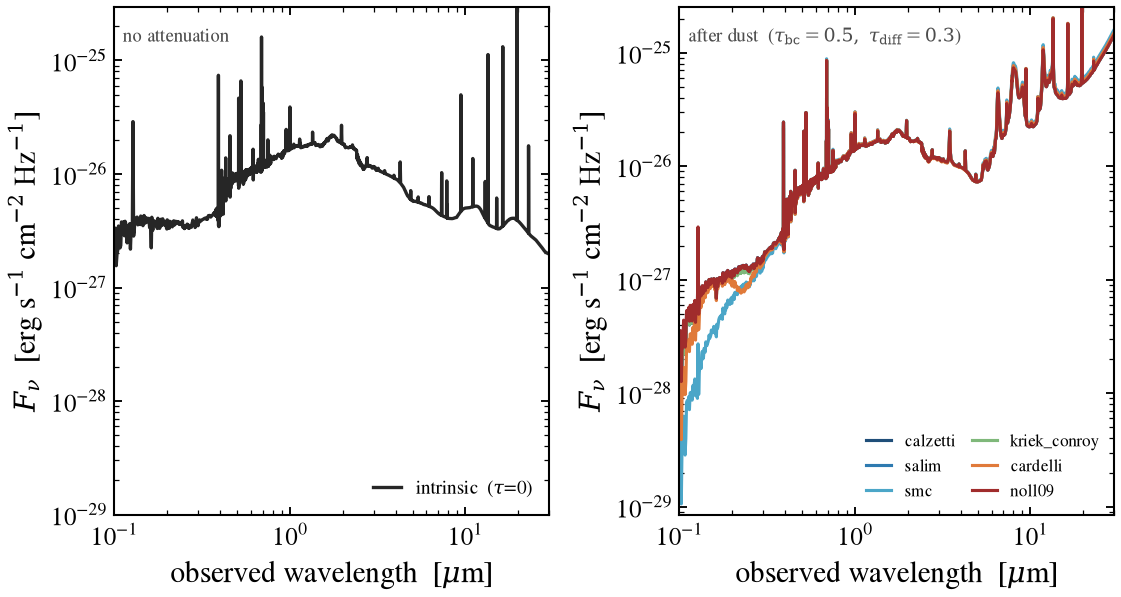

In [17]:
fig = plt.figure(figsize=(8.6, 4.4))
gs = fig.add_gridspec(1, 2, wspace=0.30)

# Fixed SFH for all dust laws
truth_sfh = {
    "sfh_tsnorm_log_total_mass": np.log10(1e10),
    "sfh_tsnorm_peak_lbt_gyr": 3.0,
    "sfh_tsnorm_width_gyr": 2.5,
    "sfh_tsnorm_skew": 0.2,
    "sfh_tsnorm_trunc": 4.0,
}

# LEFT: Intrinsic SED (zero dust) as reference
ax_ref = fig.add_subplot(gs[0])

# Base groups for no-dust comparison
groups_nodust = {
    "sfh": {
        "type": "tsnorm",
        "log_total_mass": Fixed(np.log10(1e10)),
        "peak_lbt_gyr": Fixed(3.0),
        "width_gyr": Fixed(2.5),
        "skew": Fixed(0.2),
        "trunc": Fixed(4.0),
    },
    "dust_attenuation": {
        "type": "two_component",
        "law": "calzetti",
        "all_params": Fixed(
            DEFAULT
        ),  # dust-free comparison: everything pinned, taus at zero (#1995)
        "tau_bc": Fixed(0.0),
        "tau_diff": Fixed(0.0),
        "slope": Fixed(-0.7),
    },
    "dust_emission": {"type": "dale2014", "all_params": Fixed(DEFAULT)},
    "neb": {"type": "cue", "all_params": Fixed(DEFAULT)},
    "redshift": Fixed(z),
    "igm": {"type": "none"},
}
spec_nodust = parse_groups(**groups_nodust)
model_nodust = SEDModel(spec_nodust, ssp, observation=observation)

truth_nodust = {
    **truth_sfh,
    "met_logzsol": -0.1,
    "dust_tau_bc": 0.0,
    "dust_tau_diff": 0.0,
    "dust_slope": -0.7,
    "redshift": z,
}

pred_nodust = model_nodust.predict(truth_nodust)
wave_obs_um = np.asarray(pred_nodust.wave_rest) * (1.0 + z) / 1e4
sed_fnu_nodust = np.asarray(units.lnu_to_fnu(pred_nodust.rest_sed(), dl_cm, z))

# Clip to visible window — keeps log-autoscale honest
_mask_ref = (wave_obs_um >= 0.1) & (wave_obs_um <= 30)
ax_ref.loglog(
    wave_obs_um[_mask_ref],
    sed_fnu_nodust[_mask_ref],
    lw=1.6,
    color=C_TRUTH,
    label=r"intrinsic  ($\tau$=0)",
)
ax_ref.set_xlabel(r"observed wavelength  [$\mu$m]")
ax_ref.set_ylabel(r"$F_\nu$  [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
ax_ref.set_xlim(0.1, 30)
_ymed_ref = np.median(sed_fnu_nodust[_mask_ref & (sed_fnu_nodust > 0)])
ax_ref.set_ylim(_ymed_ref / 1e3, _ymed_ref * 30)
ax_ref.legend(loc="lower right", frameon=False, fontsize=9)
ax_ref.text(
    0.02,
    0.96,
    "no attenuation",
    transform=ax_ref.transAxes,
    ha="left",
    va="top",
    fontsize=9,
    color="0.3",
)

# RIGHT: SEDs with each dust law
ax_sed = fig.add_subplot(gs[1])

# Reuse base and swap the attenuation law
for idx, dust_law in enumerate(dust_laws):
    groups_dustlaw_fig = {
        "sfh": {
            "type": "tsnorm",
            "log_total_mass": Fixed(np.log10(1e10)),
            "peak_lbt_gyr": Fixed(3.0),
            "width_gyr": Fixed(2.5),
            "skew": Fixed(0.2),
            "trunc": Fixed(4.0),
        },
        "dust_attenuation": {
            "type": "two_component",
            "law": dust_law,
            "all_params": Fixed(DEFAULT),  # deliberately all-fixed for this figure (#1995)
            "tau_bc": Fixed(0.5),
            "tau_diff": Fixed(0.3),
            "slope": Fixed(-0.7),
        },
        "dust_emission": {"type": "dale2014", "all_params": Fixed(DEFAULT)},
        "neb": {"type": "cue", "all_params": Fixed(DEFAULT)},
        "redshift": Fixed(z),
        "igm": {"type": "none"},
    }
    spec = parse_groups(**groups_dustlaw_fig)
    model = SEDModel(spec, ssp, observation=observation)

    truth = {
        **truth_sfh,
        "met_logzsol": -0.1,
        "dust_tau_bc": 0.5,
        "dust_tau_diff": 0.3,
        "dust_slope": -0.7,
        "redshift": z,
    }

    pred = model.predict(truth)
    wave_obs_um = np.asarray(pred.wave_rest) * (1.0 + z) / 1e4
    sed_fnu = np.asarray(units.lnu_to_fnu(pred.rest_sed(), dl_cm, z))

    palette = ["#1f4e79", "#2e7ab0", "#4ba6c8", "#7fb87a", "#e07a3a", "#a02c2c", "#5e3a8c"]
    color = palette[idx % len(palette)]
    _m = (wave_obs_um >= 0.1) & (wave_obs_um <= 30)
    ax_sed.loglog(wave_obs_um[_m], sed_fnu[_m], lw=1.5, label=dust_law, color=color)
    if idx == 0:
        _ymed_sed = np.median(sed_fnu[_m & (sed_fnu > 0)])

ax_sed.set_xlabel(r"observed wavelength  [$\mu$m]")
ax_sed.set_ylabel(r"$F_\nu$  [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
ax_sed.set_xlim(0.1, 30)
ax_sed.set_ylim(_ymed_sed / 1e3, _ymed_sed * 30)
ax_sed.legend(
    loc="lower right", frameon=False, fontsize=8, ncol=2, handlelength=1.5, columnspacing=1.0
)
ax_sed.text(
    0.02,
    0.96,
    r"after dust  ($\tau_{\rm bc}=0.5,\ \tau_{\rm diff}=0.3$)",
    transform=ax_sed.transAxes,
    ha="left",
    va="top",
    fontsize=9,
    color="0.3",
)

fig.savefig(FIG_DIR / "04_dust_law_grid.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "04_dust_law_grid.pdf", bbox_inches="tight")

## Vary the dust emission model

Three IR templates with different assumptions: empirical energy balance
(Dale 2014), semi-analytic grain physics (DL07), and parametric blackbody.

In [18]:
dust_emissions = [
    "dale2014",
    "draine_li2007",
    "casey2012",
    "modified_blackbody",
]

print("\nDust Emission Model Comparison")
print("─" * 70)

# Base groups dict: emission type is the only thing that changes
base_groups_emission = {
    "sfh": {
        "type": "tsnorm",
        "log_total_mass": Fixed(np.log10(1e10)),
        "peak_lbt_gyr": Fixed(3.0),
        "width_gyr": Fixed(2.5),
        "skew": Fixed(0.2),
        "trunc": Fixed(4.0),
    },
    "dust_attenuation": {
        "type": "two_component",
        "law": "calzetti",
        "all_params": Fixed(DEFAULT),  # deliberately all-fixed for this demo (#1995)
        "tau_bc": Fixed(0.5),
        "tau_diff": Fixed(0.3),
        "slope": Fixed(-0.7),
    },
    "neb": {"type": "cue", "all_params": Fixed(DEFAULT)},
    "redshift": Fixed(0.05),
    "igm": {"type": "none"},
}

for emission in dust_emissions:
    try:
        # Swap emission type: one-line edit
        groups_emission_var = base_groups_emission.copy()
        groups_emission_var["dust_emission"] = {"type": emission, "all_params": Fixed(DEFAULT)}

        spec = parse_groups(**groups_emission_var)
        emission_params = [p for p in spec.free_params if p.startswith("dust_")]
        print(f"{emission:20s}  dust free params: {emission_params}")
    except Exception as e:
        print(f"{emission:20s}  SKIPPED ({str(e)[:40]}...)")


Dust Emission Model Comparison
──────────────────────────────────────────────────────────────────────
dale2014              dust free params: []
draine_li2007         dust free params: []
casey2012             dust free params: []
modified_blackbody    dust free params: []


## SED under different IR templates

Different IR templates (empirical Dale, semi-analytic DL07, observed Casey,
parametric blackbody) produce different mid-to-far IR shapes. The energy
balance check (L_IR / L_dust_absorbed ≈ 1) validates energy conservation.

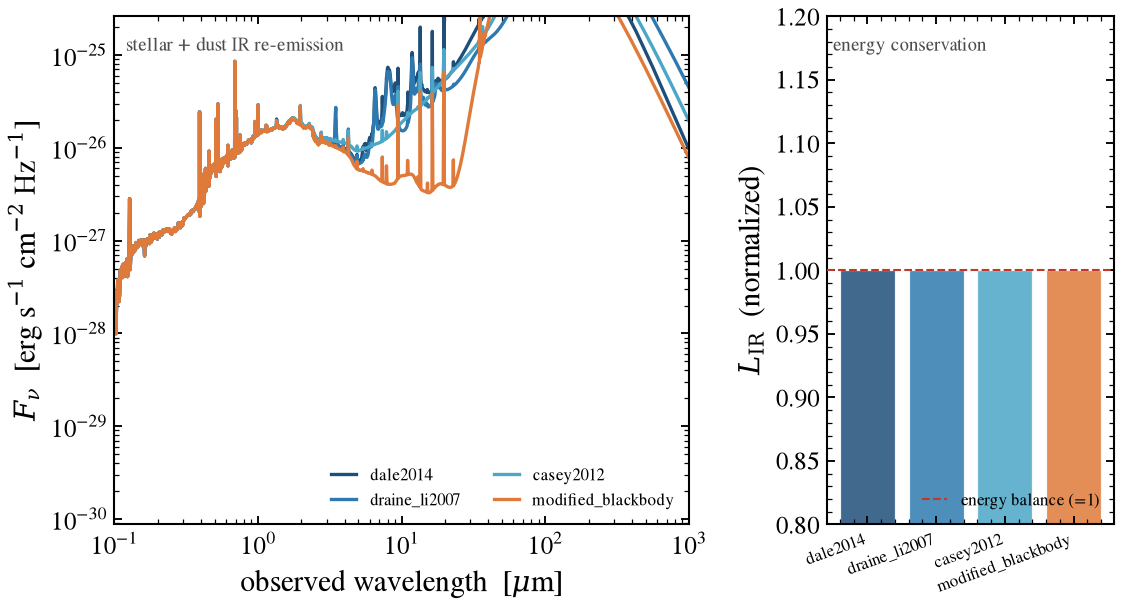

In [19]:
fig = plt.figure(figsize=(8.6, 4.4))
gs = fig.add_gridspec(1, 2, wspace=0.32, width_ratios=[2, 1])

# Fixed SFH/metallicity/dust for all emission models
truth_base = {
    "sfh_tsnorm_log_total_mass": np.log10(1e10),
    "sfh_tsnorm_peak_lbt_gyr": 3.0,
    "sfh_tsnorm_width_gyr": 2.5,
    "sfh_tsnorm_skew": 0.2,
    "sfh_tsnorm_trunc": 4.0,
    "met_logzsol": -0.1,
    "dust_tau_bc": 0.5,
    "dust_tau_diff": 0.3,
    "dust_slope": -0.7,
    "redshift": z,
}

# LEFT: SED templates
ax_sed = fig.add_subplot(gs[0])

for idx, emission in enumerate(dust_emissions):
    groups_emission_fig = {
        "sfh": {
            "type": "tsnorm",
            "log_total_mass": Fixed(np.log10(1e10)),
            "peak_lbt_gyr": Fixed(3.0),
            "width_gyr": Fixed(2.5),
            "skew": Fixed(0.2),
            "trunc": Fixed(4.0),
        },
        "dust_attenuation": {
            "type": "two_component",
            "law": "calzetti",
            "all_params": Fixed(DEFAULT),  # deliberately all-fixed for this figure (#1995)
            "tau_bc": Fixed(0.5),
            "tau_diff": Fixed(0.3),
            "slope": Fixed(-0.7),
        },
        "dust_emission": {"type": emission, "all_params": Fixed(DEFAULT)},
        "neb": {"type": "cue", "all_params": Fixed(DEFAULT)},
        "redshift": Fixed(z),
        "igm": {"type": "none"},
    }
    spec = parse_groups(**groups_emission_fig)
    model = SEDModel(spec, ssp, observation=observation)

    pred = model.predict(truth_base)
    wave_obs_um = np.asarray(pred.wave_rest) * (1.0 + z) / 1e4
    sed_fnu = np.asarray(units.lnu_to_fnu(pred.rest_sed(), dl_cm, z))

    color = PALETTE_SEQ[idx % len(PALETTE_SEQ)]
    _m_em = (wave_obs_um >= 0.1) & (wave_obs_um <= 1000)
    ax_sed.loglog(wave_obs_um[_m_em], sed_fnu[_m_em], lw=1.6, label=emission, color=color)
    if idx == 0:
        _ymed_em = np.median(sed_fnu[_m_em & (sed_fnu > 0)])

ax_sed.set_xlabel(r"observed wavelength  [$\mu$m]")
ax_sed.set_ylabel(r"$F_\nu$  [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
ax_sed.set_xlim(0.1, 1000)
ax_sed.set_ylim(_ymed_em / 1e4, _ymed_em * 30)
ax_sed.legend(loc="lower right", frameon=False, fontsize=8, ncol=2)
ax_sed.text(
    0.02,
    0.96,
    "stellar + dust IR re-emission",
    transform=ax_sed.transAxes,
    ha="left",
    va="top",
    fontsize=9,
    color="0.3",
)

# RIGHT: Energy balance bar chart
ax_balance = fig.add_subplot(gs[1])

# Extract derived quantities (L_IR, L_dust_absorbed) from each model
l_ir_values = []
for emission in dust_emissions:
    groups_energy_fig = {
        "sfh": {
            "type": "tsnorm",
            "log_total_mass": Fixed(np.log10(1e10)),
            "peak_lbt_gyr": Fixed(3.0),
            "width_gyr": Fixed(2.5),
            "skew": Fixed(0.2),
            "trunc": Fixed(4.0),
        },
        "dust_attenuation": {
            "type": "two_component",
            "law": "calzetti",
            "all_params": Fixed(DEFAULT),  # deliberately all-fixed for this figure (#1995)
            "tau_bc": Fixed(0.5),
            "tau_diff": Fixed(0.3),
            "slope": Fixed(-0.7),
        },
        "dust_emission": {"type": emission, "all_params": Fixed(DEFAULT)},
        "neb": {"type": "cue", "all_params": Fixed(DEFAULT)},
        "redshift": Fixed(z),
        "igm": {"type": "none"},
    }
    spec = parse_groups(**groups_energy_fig)
    model = SEDModel(spec, ssp, observation=observation)
    pred = model.predict(truth_base)
    derived = pred.properties
    l_ir = derived.get("L_ir_rest", 1.0)  # Use fallback 1.0 if not available
    l_ir_values.append(l_ir)

# Normalize by first value for visibility
l_ir_norm = np.array(l_ir_values) / l_ir_values[0]

colors = [PALETTE_SEQ[i % len(PALETTE_SEQ)] for i in range(len(dust_emissions))]
ax_balance.bar(
    range(len(dust_emissions)),
    l_ir_norm,
    color=colors,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.6,
)
ax_balance.axhline(y=1.0, color=C_DATA, ls="--", lw=1.0, label="energy balance (=1)", zorder=3)
ax_balance.set_ylabel(r"$L_{\rm IR}$  (normalized)")
ax_balance.set_xticks(range(len(dust_emissions)))
ax_balance.set_xticklabels(dust_emissions, rotation=20, ha="right", fontsize=8)
ax_balance.set_ylim(0.8, 1.2)
ax_balance.legend(loc="lower right", frameon=False, fontsize=8)
ax_balance.text(
    0.02,
    0.96,
    "energy conservation",
    transform=ax_balance.transAxes,
    ha="left",
    va="top",
    fontsize=9,
    color="0.3",
)

fig.savefig(FIG_DIR / "04_dust_emission_grid.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "04_dust_emission_grid.pdf", bbox_inches="tight")
plt.show()

## Free vs fixed parameters

The same physical model with different parameters freed. The wildcard
directives set the free/fixed status; `summary()` shows the result.

In [20]:
print("\nFree vs Fixed Parameter Tracking")
print("─" * 70)

# Build a reference model to show summary()
groups_ref = {
    "sfh": {"type": "tsnorm", "all_params": FREE, "met_logzsol": Fixed(-0.1)},
    "dust_attenuation": {
        "type": "two_component",
        "law": "calzetti",
        "all_params": FREE,
        "slope": Fixed(-0.7),
    },
    "dust_emission": {"type": "dale2014", "all_params": Fixed(DEFAULT)},
    "redshift": Uniform(0.01, 0.1),
    "igm": {"type": "none"},
}
spec_ref = parse_groups(**groups_ref)
print("\nModel Summary (using Parameters.summary_str()):")
print(spec_ref.summary_str())

# Model 1: free redshift
groups_free_z = {
    "sfh": {"type": "tsnorm", "all_params": FREE, "met_logzsol": Fixed(-0.1)},
    "dust_attenuation": {
        "type": "two_component",
        "law": "calzetti",
        "all_params": FREE,
        "slope": Fixed(-0.7),
    },
    "dust_emission": {"type": "dale2014", "all_params": Fixed(DEFAULT)},
    "redshift": Uniform(0.01, 0.1),  # FREE
    "igm": {"type": "none"},
}
spec_free_z = parse_groups(**groups_free_z)

# Model 2: fixed redshift
groups_fixed_z = {
    "sfh": {"type": "tsnorm", "all_params": FREE, "met_logzsol": Fixed(-0.1)},
    "dust_attenuation": {
        "type": "two_component",
        "law": "calzetti",
        "all_params": FREE,
        "slope": Fixed(-0.7),
    },
    "dust_emission": {"type": "dale2014", "all_params": Fixed(DEFAULT)},
    "redshift": Fixed(0.05),  # FIXED
    "igm": {"type": "none"},
}
spec_fixed_z = parse_groups(**groups_fixed_z)

print(f"\nFree redshift       : {len(spec_free_z.free_params):2d} free params")
print(f"  {spec_free_z.free_params}")
print()
print(f"Fixed redshift      : {len(spec_fixed_z.free_params):2d} free params")
print(f"  {spec_fixed_z.free_params}")
print()
print("Difference in free_params due to redshift:")
print(f"  Free z   has 'redshift': {'redshift' in spec_free_z.free_params}")
print(f"  Fixed z has 'redshift': {'redshift' in spec_fixed_z.free_params}")


Free vs Fixed Parameter Tracking
──────────────────────────────────────────────────────────────────────

Model Summary (using Parameters.summary_str()):
Parameters  SFH: tsnorm
──────────────────────────────────────────────────────────────────
  Dimensions:  8 free, + 33 fixed
  Modules:     dust_emission=dale2014, dust_attenuation_law=calzetti

  Parameter                        Prior                      Bounds                 Source
  ──────────────────────────────────────────────────────────────────────────────────────────
  dust_tau_bc                      Uniform(0.0, 4.0)          [0, 4]                 [all_params FREE]
  dust_tau_diff                    Uniform(0.0, 3.0)          [0, 3]                 [all_params FREE]
  redshift                         Uniform(0.01, 0.1)         [0.01, 0.1]            [user]
  sfh_tsnorm_log_total_mass        Uniform(7.0, 12.5)         [7, 12.5]              [all_params FREE]
  sfh_tsnorm_peak_lbt_gyr          Uniform(0.5, 12.0)         [0.

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_81771/743317232.py:17: WildcardPartialFreeWarning: sfh={'all_params': FREE} no longer frees metallicity parameters when there is no explicit met block. Before this change, met_logzsol (and other met_* params) were freed by the sfh wildcard.

To free metallicity parameters explicitly, pass either:
  met={'all_params': FREE}
or:
  met={'logzsol': Uniform(-2, 0.2)}

Issue #1796
  spec_ref = parse_groups(**groups_ref)
/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_81771/743317232.py:17: WildcardPartialFreeWarning: 'all_params: FREE' freed 2 of 3 parameters in group 'dust_attenuation'. These have no declared prior, only Fixed defaults, so they stay pinned:
  dust_f_obscuration
The fit will run with that physics held constant. Pass explicit priors for the ones you meant to vary, e.g. dust_attenuation={'dust_f_obscuration': Uniform(lo, hi)}, or filter WildcardPartialFreeWarning if this is deliberate.
  spec_ref = parse_gro

## Forward-model timing

A single prediction against 50 sequential ones. The first call pays the JIT
compile; after that each prediction is cheap, and a `vmap` over parameters
would collapse the 50 into one batched call.

In [21]:
# Build a representative model
groups_perf = {
    "sfh": {
        "type": "tsnorm",
        "log_total_mass": Fixed(np.log10(1e10)),
        "peak_lbt_gyr": Fixed(3.0),
        "width_gyr": Fixed(2.5),
        "skew": Fixed(0.2),
        "trunc": Fixed(4.0),
    },
    "dust_attenuation": {
        "type": "two_component",
        "law": "calzetti",
        "all_params": Fixed(DEFAULT),  # deliberately all-fixed for this demo (#1995)
        "tau_bc": Fixed(0.5),
        "tau_diff": Fixed(0.3),
        "slope": Fixed(-0.7),
    },
    "dust_emission": {"type": "dale2014", "all_params": Fixed(DEFAULT)},
    "redshift": Fixed(0.05),
    "igm": {"type": "none"},
}
spec_perf = parse_groups(**groups_perf)
model_perf = SEDModel(spec_perf, ssp, observation=observation)

# Base truth dict
truth_perf = {
    "sfh_tsnorm_log_total_mass": np.log10(1e10),
    "sfh_tsnorm_peak_lbt_gyr": 3.0,
    "sfh_tsnorm_width_gyr": 2.5,
    "sfh_tsnorm_skew": 0.2,
    "sfh_tsnorm_trunc": 4.0,
    "met_logzsol": -0.1,
    "dust_tau_bc": 0.5,
    "dust_tau_diff": 0.3,
    "dust_slope": -0.7,
    "redshift": 0.05,
}

# Time: single call
t0 = time.perf_counter()
_ = model_perf.predict_photometry(truth_perf)
t_single = time.perf_counter() - t0

# Time: 50 sequential calls (with parameter variations)
n_iter = 50
t0 = time.perf_counter()
for i in range(n_iter):
    truth_var = truth_perf.copy()
    truth_var["dust_tau_bc"] = 0.5 + 0.01 * np.sin(i / 10.0)
    _ = model_perf.predict_photometry(truth_var)
t_loop = time.perf_counter() - t0

print("\nForward Model Performance")
print("─" * 70)
print(f"Single prediction:            {t_single * 1000:.2f} ms")
print(f"50 sequential predictions:    {t_loop:.3f} s ({t_loop / n_iter * 1000:.2f} ms per call)")
print(f"Per-call overhead (amortized):{(t_loop / n_iter - t_single) * 1000:.2f} ms")
print()
print("Once compiled, each call is ~10-30 ms: a Python loop is fine for a")
print("sensitivity study, vmap() when you want the whole batch at once.")


Forward Model Performance
──────────────────────────────────────────────────────────────────────
Single prediction:            692.19 ms
50 sequential predictions:    0.696 s (13.92 ms per call)
Per-call overhead (amortized):-678.27 ms

Once compiled, each call is ~10-30 ms: a Python loop is fine for a
sensitivity study, vmap() when you want the whole batch at once.


## Where to go next

Key methods and entry points worth remembering:

- `recipes.*()` — curated starting points
- `SEDModel.build(..., filters=...)` — build and evaluate in one line
- `model.spec.to_groups()` — pull the structure back out to edit
- `model.spec.summary_str()` — where each parameter value came from

From here, the [`quickstart`](00_quickstart.ipynb)
runs a real fit and reads its posterior;
[`06_fitting_spectroscopy`](06_fitting_spectroscopy.ipynb) breaks age, dust,
and metallicity degeneracies with a spectrum. Stochastic SFHs live
under `sfh={'type': ['dpl', 'field'], ...}`; AGN under
`agn={'disc': ..., 'torus': ...}`. Build your own component, register it,
and the parameter tracking and forward model pick it up unchanged.